# Cross-Repo AAI Comparison

Compares per-framework summary stats (mean / median scores, latency, tokens, variation-question quality) across multiple repositories.

**Inputs.** Every CSV in `cross_repo_exports/` named `repo_summary_<REPO>.csv`. Each file is produced by Section 9 of [analysis.ipynb](analysis.ipynb) after running the single-repo notebook on that repo's `runs/` directory.

**Workflow.**
1. Run the single-repo notebook for each repo &mdash; it writes `repo_summary_<REPO>.csv` here.
2. Run this notebook to compare them all side-by-side.

**Conventions.**
- The combined `repo_df` is treated as immutable; every filter / transformation calls `.copy()`.
- Framework order and colors mirror the single-repo notebook for visual consistency.

## 1. Setup

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from aai_loader import FRAMEWORK_COLORS, FRAMEWORK_ORDER

CROSS_REPO_DIR = Path.cwd() / "cross_repo_exports"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

# print(f"CROSS_REPO_DIR = {CROSS_REPO_DIR.name}")


## 2. Load every repo summary

Concatenates every `repo_summary_<REPO>.csv` into one long DataFrame indexed by `(repo, framework)`.

In [2]:
summary_files = sorted(CROSS_REPO_DIR.glob("repo_summary_*.csv"))
assert summary_files, (
    f"No repo_summary_*.csv found in {CROSS_REPO_DIR}. "
    "Run Section 9 of analysis.ipynb for each repo first."
)

repo_df = pd.concat([pd.read_csv(p) for p in summary_files], ignore_index=True).copy()
# Enforce framework order for plotting.
repo_df["framework"] = pd.Categorical(
    repo_df["framework"], categories=FRAMEWORK_ORDER, ordered=True
)
repo_df = repo_df.sort_values(["repo", "framework"]).reset_index(drop=True)

print(f"Loaded {len(summary_files)} repo summary file(s).")
print("Repos:     ", sorted(repo_df['repo'].unique()))
print("Frameworks:", list(repo_df['framework'].cat.categories))
repo_df

Loaded 1 repo summary file(s).
Repos:      ['MovieHub']
Frameworks: ['Single Shot', 'Critic Off', 'Critic On']


,repo,framework,n_runs,core_score_mean,core_score_median,overall_score_mean,overall_score_median,duration_mean_s,duration_median_s,input_tokens_mean,output_tokens_mean,total_tokens_mean,variation_pct_unanswered,variation_pct_strong_answer
0,MovieHub,Single Shot,28,93.061,91.429,58.571,58.82,8.143,7.825,2973.000,526.536,3499.536,16.071,9.643
1,MovieHub,Critic Off,28,96.633,97.143,58.276,58.82,24.786,24.088,21414.714,1813.643,23228.357,22.500,11.786
2,MovieHub,Critic On,28,96.429,97.143,62.605,60.59,48.238,47.842,30851.714,3631.321,34483.036,18.214,19.286


## 3. Headline scoreboard

One row per `(repo, framework)` with the headline metrics. Use this as the at-a-glance table for slides.

In [3]:
scoreboard = (
    repo_df.set_index(["repo", "framework"])[
        [
            "core_score_mean",
            "overall_score_mean",
            "duration_mean_s",
            "total_tokens_mean",
            "variation_pct_unanswered",
            "variation_pct_strong_answer",
        ]
    ]
    .round(2)
    .copy()
)
scoreboard

core_score_mean  overall_score_mean  duration_mean_s  total_tokens_mean  variation_pct_unanswered  variation_pct_strong_answer
repo     framework                                                                                                                                  
MovieHub Single Shot            93.06               58.57             8.14            3499.54                     16.07                         9.64
         Critic Off             96.63               58.28            24.79           23228.36                     22.50                        11.79
         Critic On              96.43               62.60            48.24           34483.04                     18.21                        19.29

## 4. Score comparison across repos

Grouped bars: each repo gets a cluster of three bars (one per framework). Reveals which repos AAI handles well and which it struggles on.

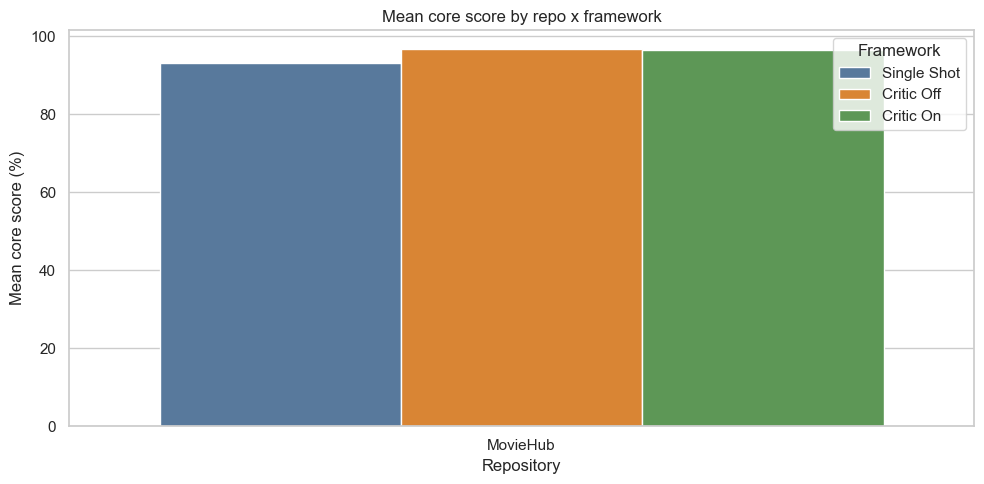

In [8]:
def _grouped_bar(metric: str, ylabel: str, title_text: str, ax: plt.Axes | None = None) -> plt.Axes:
    plot_df = repo_df[["repo", "framework", metric]].copy()
    if ax is None:
        _, ax = plt.subplots(figsize=(max(8, 1.6 * plot_df["repo"].nunique() + 4), 5))
    sns.barplot(
        data=plot_df, x="repo", y=metric, hue="framework",
        hue_order=FRAMEWORK_ORDER, palette=FRAMEWORK_COLORS, ax=ax,
    )
    ax.set_title(title_text)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Repository")
    ax.legend(title="Framework", loc="best")
    return ax


fig, ax = plt.subplots(figsize=(10, 5))
_grouped_bar("core_score_mean", "Mean core score (%)", "Mean core score by repo x framework", ax=ax)
plt.tight_layout()
plt.show()


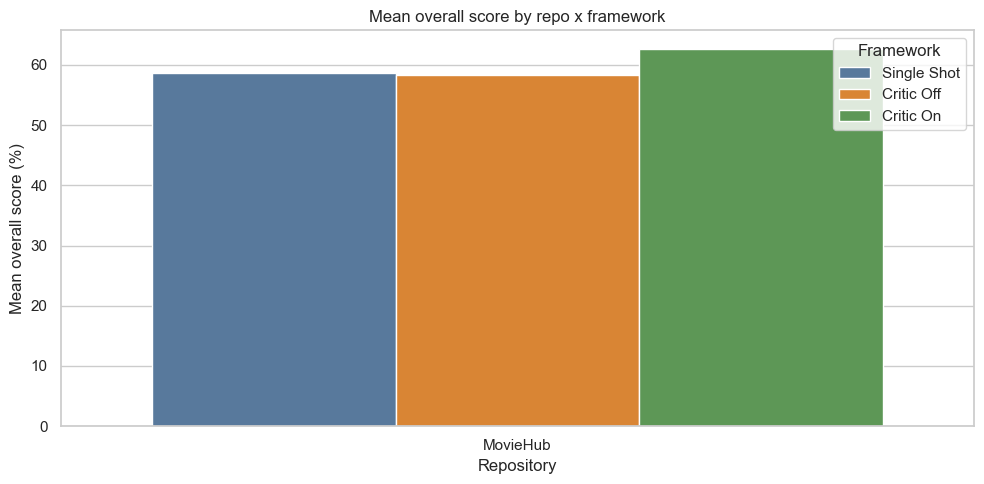

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
_grouped_bar("overall_score_mean", "Mean overall score (%)", "Mean overall score by repo x framework", ax=ax)
plt.tight_layout()
plt.show()


## 5. Latency &amp; token cost across repos

Same grouped-bar layout but for the cost-side metrics. Useful for spotting repos where (e.g.) Critic On's gain isn't worth the token blow-up.

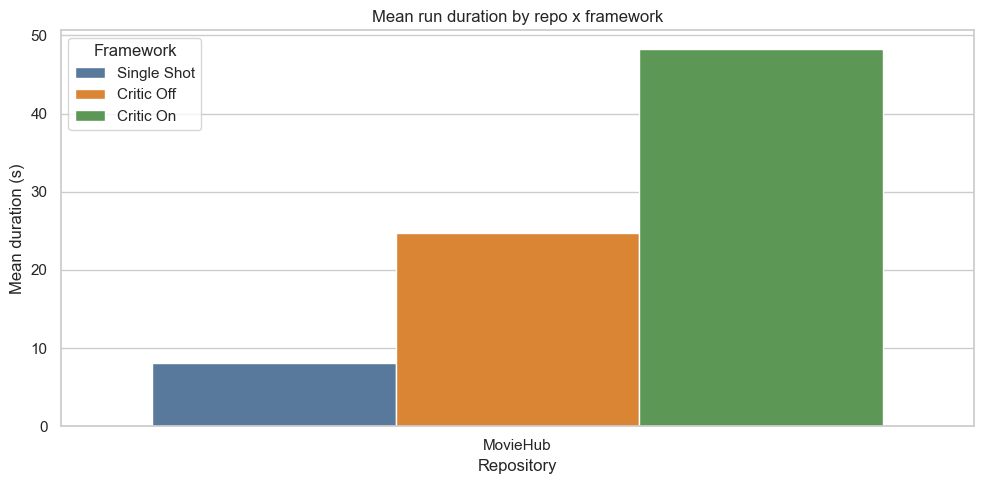

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
_grouped_bar("duration_mean_s", "Mean duration (s)", "Mean run duration by repo x framework", ax=ax)
plt.tight_layout()
plt.show()


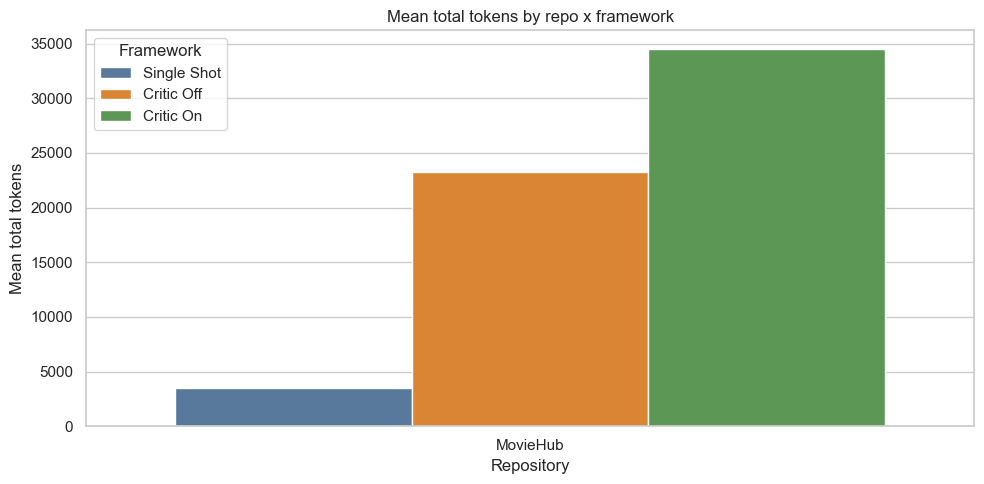

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
_grouped_bar("total_tokens_mean", "Mean total tokens", "Mean total tokens by repo x framework", ax=ax)
plt.tight_layout()
plt.show()


## 6. Variation-question quality across repos

`pct_unanswered` = % of variation questions that scored 0 ("diagram had nothing to say"). `pct_strong_answer` = % scoring &ge; 4. A good run has low unanswered + high strong-answer.

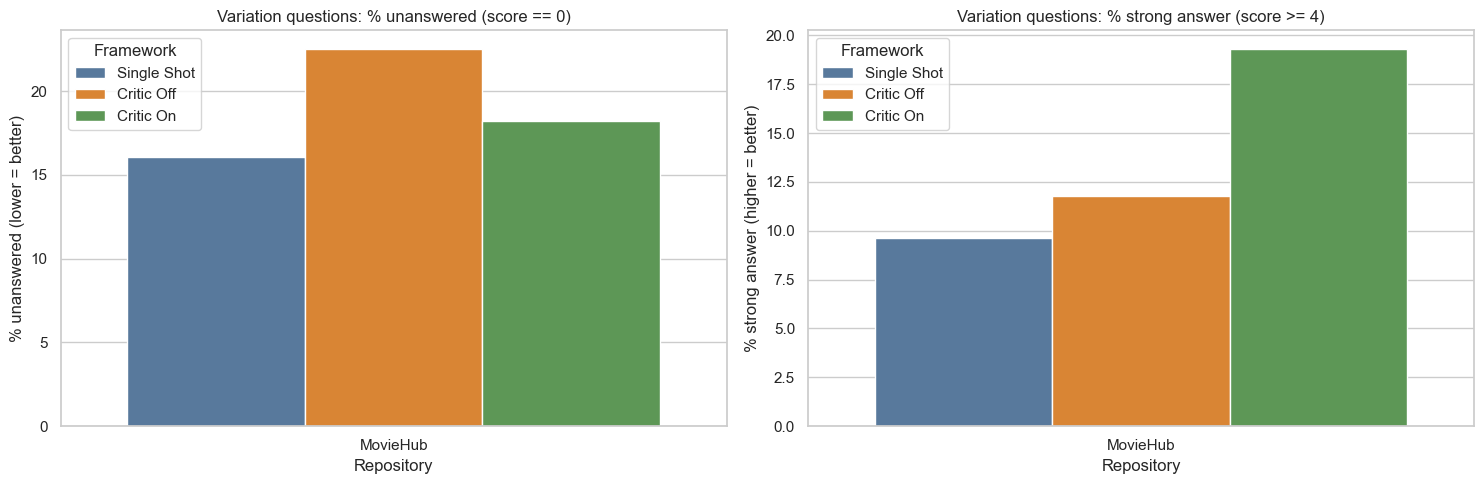

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
_grouped_bar(
    "variation_pct_unanswered", "% unanswered (lower = better)",
    "Variation questions: % unanswered (score == 0)", ax=axes[0],
)
_grouped_bar(
    "variation_pct_strong_answer", "% strong answer (higher = better)",
    "Variation questions: % strong answer (score >= 4)", ax=axes[1],
)
plt.tight_layout()
plt.show()

## 7. Critic uplift per repo

How much does Critic On gain over Critic Off / Single Shot **on each repo**? Positive bars mean Critic On scored higher on that repo.

In [13]:
wide = (
    repo_df.pivot_table(
        index="repo", columns="framework",
        values=["overall_score_mean", "core_score_mean", "total_tokens_mean", "duration_mean_s"],
        observed=False,
    )
    .copy()
)

uplift = pd.DataFrame(index=wide.index)
for metric in ["overall_score_mean", "core_score_mean"]:
    uplift[f"{metric}__CriticOn_vs_CriticOff"] = (
        wide[(metric, "Critic On")] - wide[(metric, "Critic Off")]
    )
    uplift[f"{metric}__CriticOn_vs_SingleShot"] = (
        wide[(metric, "Critic On")] - wide[(metric, "Single Shot")]
    )
uplift = uplift.round(2)
uplift

,overall_score_mean__CriticOn_vs_CriticOff,overall_score_mean__CriticOn_vs_SingleShot,core_score_mean__CriticOn_vs_CriticOff,core_score_mean__CriticOn_vs_SingleShot
repo,,,,
MovieHub,4.33,4.03,-0.2,3.37


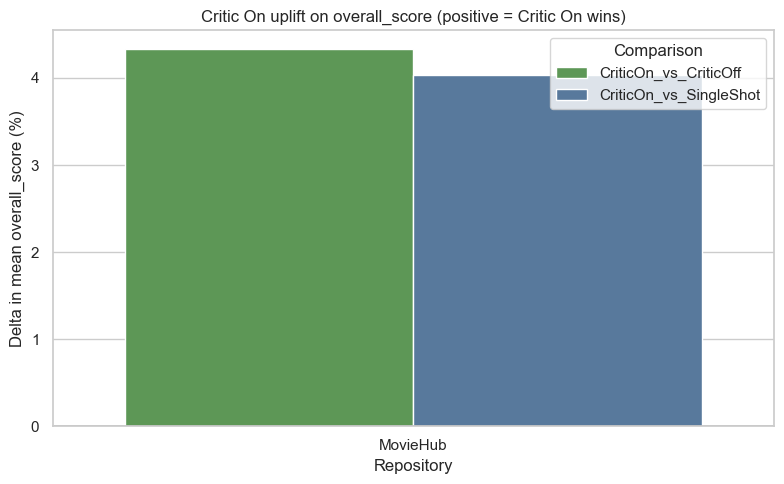

In [14]:
uplift_long = (
    uplift.filter(like="overall_score_mean")
    .reset_index()
    .melt(id_vars="repo", var_name="comparison", value_name="delta")
    .copy()
)
uplift_long["comparison"] = uplift_long["comparison"].str.replace(
    "overall_score_mean__", "", regex=False
)

fig, ax = plt.subplots(figsize=(max(8, 1.6 * repo_df["repo"].nunique() + 4), 5))
sns.barplot(
    data=uplift_long, x="repo", y="delta", hue="comparison",
    palette={"CriticOn_vs_CriticOff": "#54A24B", "CriticOn_vs_SingleShot": "#4C78A8"},
    ax=ax,
)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Critic On uplift on overall_score (positive = Critic On wins)")
ax.set_ylabel("Delta in mean overall_score (%)")
ax.set_xlabel("Repository")
ax.legend(title="Comparison", loc="best")
plt.tight_layout()
plt.show()

## 8. Cost vs quality scatter

One point per `(repo, framework)`. X = mean total tokens (cost). Y = mean overall score (quality). Color = framework, label = repo. Repos in the upper-left are the bargain; upper-right means quality scales with cost; lower-right means you're paying for nothing.

In [15]:
fig = px.scatter(
    repo_df,
    x="total_tokens_mean",
    y="overall_score_mean",
    color="framework",
    symbol="repo",
    text="repo",
    category_orders={"framework": FRAMEWORK_ORDER},
    color_discrete_map=FRAMEWORK_COLORS,
    hover_data=["core_score_mean", "duration_mean_s", "variation_pct_strong_answer"],
    title="Cost vs quality across repos",
)
fig.update_traces(textposition="top center")
fig.update_layout(height=550, xaxis_title="Mean total tokens (cost)", yaxis_title="Mean overall score (quality, %)")
fig.show()